In [184]:
# Install the required packages
# %pip install -r notebook_packages.txt

In [185]:
import kagglehub
import pandas as pd

KAGGLE_HANDLE = "itsmrmallik/tf-countries"

file_path = "Mexico_wosis_merged(in)_temp_precip_landcover(in)_ecoregions(in).csv"
file_path = kagglehub.dataset_download(KAGGLE_HANDLE, path=file_path)

df = pd.read_csv(file_path)

print(f"Data shape: {df.shape}")
print(f"Data columns: {df.columns}")

df.head()

Data shape: (8208, 40)
Data columns: Index(['date', 'longitude', 'latitude', 'upper_depth', 'lower_depth',
       'country_name', 'region', 'continent', 'bdfi33', 'bdfiod', 'bdwsod',
       'cecph7', 'cfgr', 'cfvo', 'clay', 'ecec', 'elco20', 'elcosp', 'nitkjd',
       'orgc', 'phaq', 'phca', 'phetb1', 'phkc', 'phnf', 'phprtn', 'sand',
       'silt', 'tceq', 'totc', 'wg0010', 'wg0033', 'wg0200', 'wg1500',
       'temperature', 'precipitation', 'landcover', 'ecoregion_type',
       'zone_number', 'zone_name'],
      dtype='object')


,date,longitude,latitude,upper_depth,lower_depth,country_name,region,continent,bdfi33,bdfiod,...,wg0010,wg0033,wg0200,wg1500,temperature,precipitation,landcover,ecoregion_type,zone_number,zone_name
0,1964-??-??,-90.7319,18.6152,0,2,Mexico,Central America,Northern America,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Terrestre,2,Tropical subhúmeda
1,1964-??-??,-90.7319,18.6152,0,4,Mexico,Central America,Northern America,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Terrestre,2,Tropical subhúmeda
2,1964-??-??,-90.7319,18.6152,0,4,Mexico,Central America,Northern America,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Terrestre,2,Tropical subhúmeda
3,1964-??-??,-90.7319,18.6152,0,4,Mexico,Central America,Northern America,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Terrestre,2,Tropical subhúmeda
4,1964-??-??,-90.7319,18.6152,0,4,Mexico,Central America,Northern America,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Terrestre,2,Tropical subhúmeda


In [186]:
TARGET = "tceq" # target variable to predict orgc or tceq
UNITS = "(g/kg)"
COUNTRY = "Mexico"
NUMERIC_FEATURES = ['upper_depth','lower_depth','silt','clay','elcosp','phaq','sand','temperature','precipitation']
CATEGORICAL_FEATURES = ['landcover', 'zone_number']

# save plots to a directory
import os
OUTPUT_DIR = f"D:/tierra/outputs/plots/{COUNTRY}-{TARGET}-{UNITS.replace('(','').replace(')','').replace('/','')}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

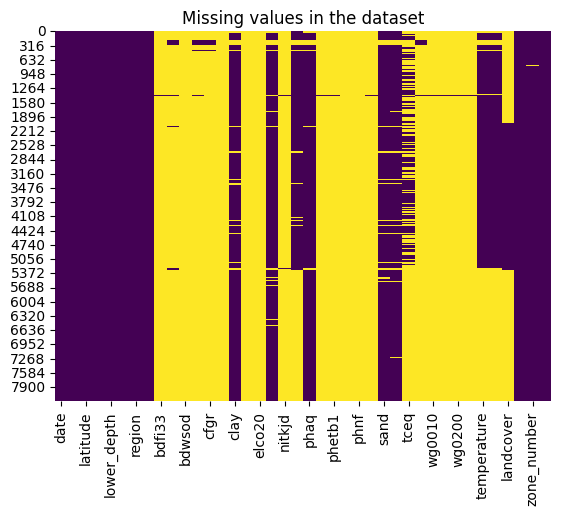

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_missing_values(df):
    # sns plot missing values
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title("Missing values in the dataset")
    # save the plot
    plt.savefig(f"{OUTPUT_DIR}/missing_values.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_missing_values(df)

In [188]:
def preprocess_zone(df):
    # set zone_number as categorical
    df['zone_number'] = df['zone_number'].astype('category').copy()

    # update zone number romans to numeric
    df['zone_number'] = df['zone_number'].cat.rename_categories({'VII': 7, 'VI': 6})

    return df

def preprocess_data(df, target):
    # drop unnecessary columns if exists
    drop_columns = ['country_name', 'region', 'continent', 'ecoregion_type', 'zone_name']
    df.drop(columns=drop_columns, inplace=True, errors='ignore')
    
    # drop missing values in target column
    df.dropna(subset=[target], inplace=True)
    
    # threshold of missing values
    threshold = 0.7 * len(df)
    # drop columns with more than 70% missing values
    cols_to_drop = [col for col in df.columns if df[col].isna().sum() > threshold and col != target]
    df.drop(columns=cols_to_drop, inplace=True)

    print(f"Data shape after dropping columns: {df.shape}")
    print(f"Data columns after dropping columns: {df.columns}")

    # drop duplicates
    df.drop_duplicates(inplace=True)

    # drop any rows with missing values
    df.dropna(inplace=True)

    df = preprocess_zone(df)

    # reset index
    df.reset_index(drop=True, inplace=True)

    return df

In [189]:
df = preprocess_data(df, TARGET)

df.head()

Data shape after dropping columns: (2628, 16)
Data columns after dropping columns: Index(['date', 'longitude', 'latitude', 'upper_depth', 'lower_depth', 'clay',
       'elcosp', 'orgc', 'phaq', 'sand', 'silt', 'tceq', 'temperature',
       'precipitation', 'landcover', 'zone_number'],
      dtype='object')


,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,tceq,temperature,precipitation,landcover,zone_number
0,6/11/2001,-115.072010,31.415775,0,10,3.0,0.1,18.0,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5
1,6/12/2001,-111.335570,31.122982,0,23,22.0,0.1,2.0,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5
2,6/12/2001,-110.948906,31.120768,0,20,12.0,0.1,6.0,5.5,72.0,16.0,0.0,16.924751,150.516754,10.0,4
3,6/12/2001,-110.095820,31.055500,0,20,32.0,0.1,7.0,6.4,54.0,14.0,0.0,16.924751,150.516754,7.0,5
4,6/13/2001,-110.830600,31.307426,0,15,20.0,0.2,11.0,6.4,64.0,16.0,0.0,16.924751,150.516754,10.0,5


# Split dataset before Training

In [190]:
# split the data into train and test sets to avoid data leakage
from sklearn.model_selection import train_test_split

# split the data into train and test sets
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# save the train and test sets to csv files
X_train.to_csv(f"{OUTPUT_DIR}/X_train.csv", index=False)
X_test.to_csv(f"{OUTPUT_DIR}/X_test.csv", index=False)
y_train.to_csv(f"{OUTPUT_DIR}/y_train.csv", index=False)
y_test.to_csv(f"{OUTPUT_DIR}/y_test.csv", index=False)

In [191]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# create a column transformer to preprocess the data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ]
)

def train_model(regressor_model, preprocessor, regressor_name):
    # create a pipeline to train the model
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor_model)
    ])

    # fit the model
    model.fit(X_train, y_train)

    # make predictions
    y_pred = model.predict(X_test)

    metrics(regressor_name, y_test, y_pred, True)

    return model, y_test, y_pred

def metrics(regressor_name, y_test, y_pred, print_metrics=False):
    # evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    if print_metrics:
        print("-" * 30)
        print(f"Model: {regressor_name} {TARGET} {UNITS} {COUNTRY}")
        print(f"Mean squared error (MSE): {mse:.4f}")
        print(f"Root mean squared error (RMSE): {rmse:.4f}")
        print(f"Mean absolute error (MAE): {mae:.4f}")
        print(f"R2: {r2:.4f}")
        print("-" * 30)

    return mae, mse, r2, rmse

def plot_feature_importance(regressor_name, model):
    # Check if model has feature_importances_ attribute
    if hasattr(model.named_steps['regressor'], 'feature_importances_'):
        # plot the feature importances
        importances = model.named_steps['regressor'].feature_importances_
        feature_names = (NUMERIC_FEATURES + 
                        model.named_steps['preprocessor']
                        .transformers_[1][1]
                        .named_steps['onehot']
                        .get_feature_names_out(CATEGORICAL_FEATURES).tolist())
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.title(f"Feature importances for {regressor_name} {TARGET} {UNITS} {COUNTRY}")
        plt.bar(range(len(importances)), importances[indices], align="center")

        plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
        plt.xlim([-1, len(importances)])
        plt.tight_layout()
        # save the plot
        plot_name = f"{regressor_name}_feature_importance.png"
        plt.savefig(os.path.join(OUTPUT_DIR, plot_name))
        print(f"Feature importance plot saved to {OUTPUT_DIR}")
        plt.show()

    else:
        print(f"Feature importance plot not available for {regressor_name}")

def plot_regression_line(regressor_name, y_test, y_pred, plot_residuals=False):
    
    mae, mse, r2, rmse = metrics(regressor_name, y_test, y_pred, False)

    # plot the predictions vs actual values
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.xlabel("Actual values")
    plt.ylabel("Predicted values")
    plt.title(f"Predictions vs Actual values for {regressor_name} {TARGET} {UNITS} {COUNTRY} \nMSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    plt.tight_layout()
    # save the plot
    plot_name = f"{regressor_name}_predicted_vs_actual.png"
    plt.savefig(os.path.join(OUTPUT_DIR, plot_name))
    print(f"Predicted vs Actual plot saved to {OUTPUT_DIR}")
    plt.show()

    if plot_residuals:
        # plot the residuals
        plt.figure(figsize=(10, 6))
        plt.scatter(y_pred, y_pred - y_test, alpha=0.5)
        plt.axhline(0, color='k', lw=2)
        plt.xlabel("Predicted values")
        plt.ylabel("Residuals")
        plt.title(f"Residuals vs Predicted values for {regressor_name} {TARGET} {UNITS} {COUNTRY}")
        plt.tight_layout()
        plot_name = f"{regressor_name}_residuals.png"
        plt.savefig(os.path.join(OUTPUT_DIR, plot_name))
        print(f"Residuals plot saved to {OUTPUT_DIR}")
        plt.show()

------------------------------
Model: Baseline model tceq (g/kg) Mexico
Mean squared error (MSE): 14899.6598
Root mean squared error (RMSE): 122.0642
Mean absolute error (MAE): 85.0476
R2: -0.0020
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-gkg


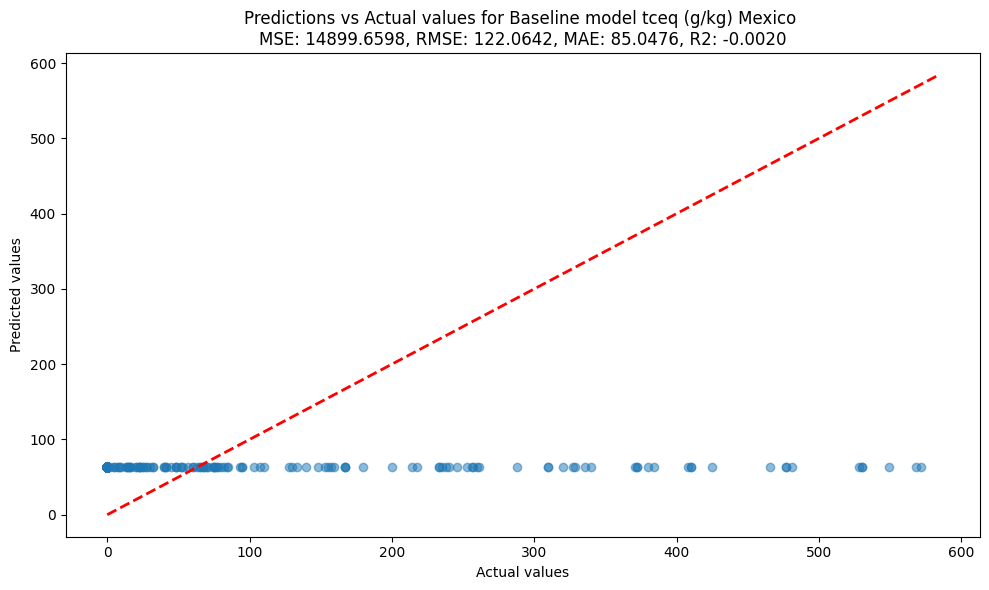

------------------------------
Model: Random Forest tceq (g/kg) Mexico
Mean squared error (MSE): 6880.5596
Root mean squared error (RMSE): 82.9491
Mean absolute error (MAE): 38.4918
R2: 0.5373
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-gkg


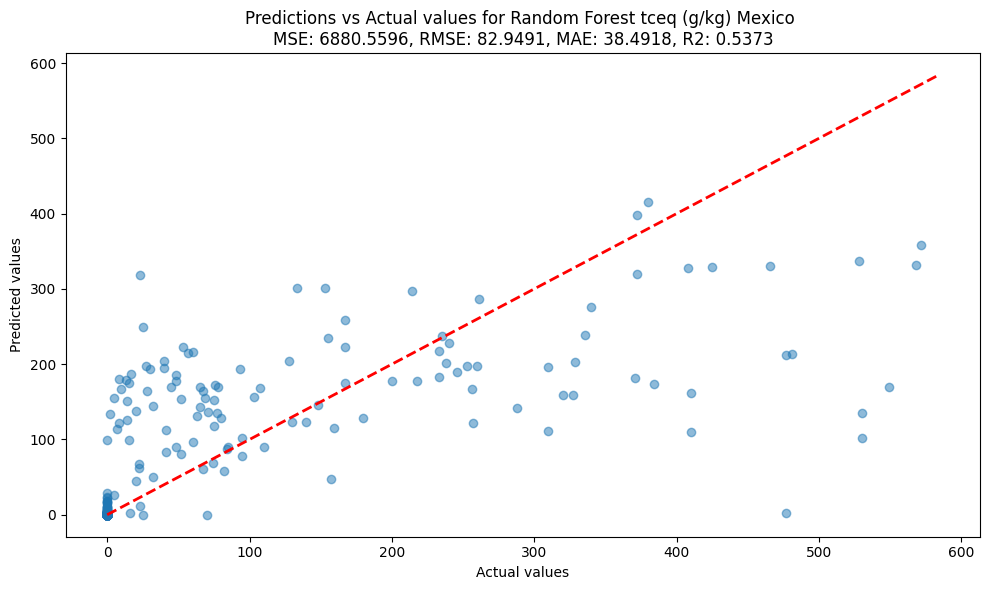

Model saved to D:/tierra/outputs/plots/Mexico-tceq-gkg\Random Forest.joblib
------------------------------
Model: Gradient Boosting tceq (g/kg) Mexico
Mean squared error (MSE): 6720.6902
Root mean squared error (RMSE): 81.9798
Mean absolute error (MAE): 39.8257
R2: 0.5480
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-gkg


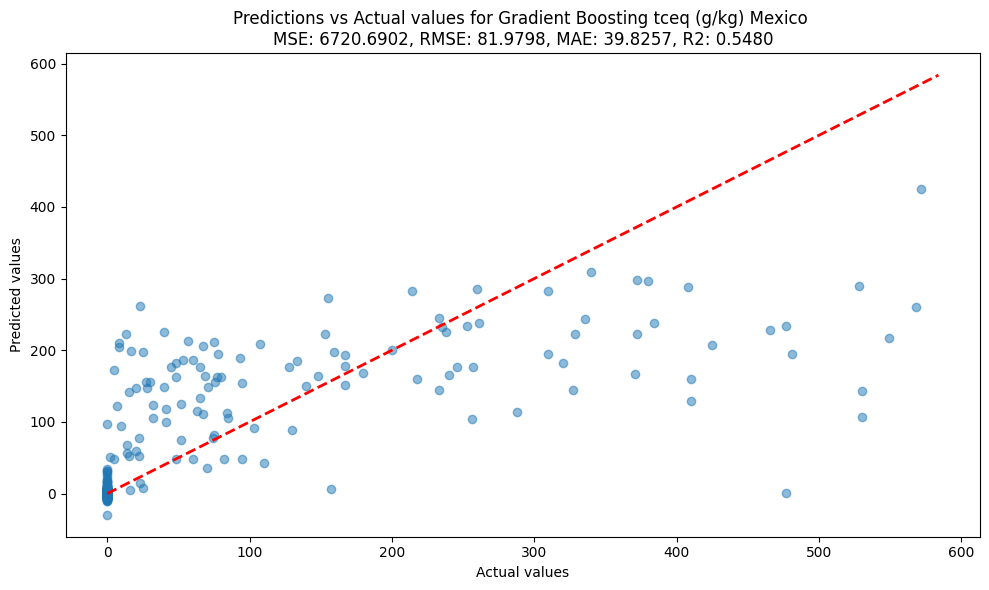

Model saved to D:/tierra/outputs/plots/Mexico-tceq-gkg\Gradient Boosting.joblib
------------------------------
Model: Linear Regression tceq (g/kg) Mexico
Mean squared error (MSE): 9763.4844
Root mean squared error (RMSE): 98.8103
Mean absolute error (MAE): 66.8825
R2: 0.3434
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-gkg


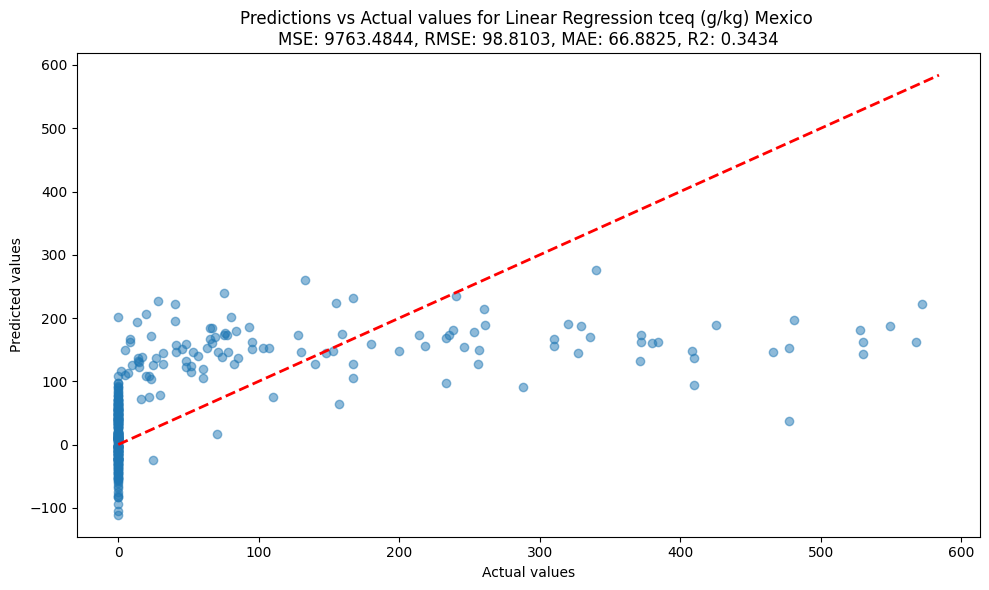

Model saved to D:/tierra/outputs/plots/Mexico-tceq-gkg\Linear Regression.joblib
------------------------------
Model: MLP Regressor tceq (g/kg) Mexico
Mean squared error (MSE): 8097.8022
Root mean squared error (RMSE): 89.9878
Mean absolute error (MAE): 43.6675
R2: 0.4554
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-gkg


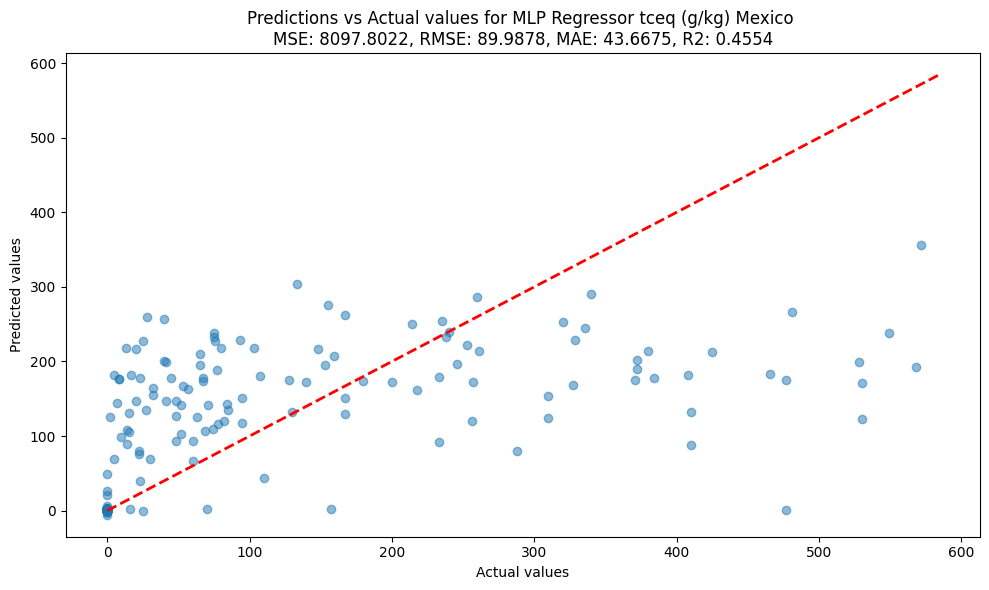

Model saved to D:/tierra/outputs/plots/Mexico-tceq-gkg\MLP Regressor.joblib
------------------------------
Model: SVR tceq (g/kg) Mexico
Mean squared error (MSE): 15999.6432
Root mean squared error (RMSE): 126.4897
Mean absolute error (MAE): 54.0772
R2: -0.0760
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-gkg


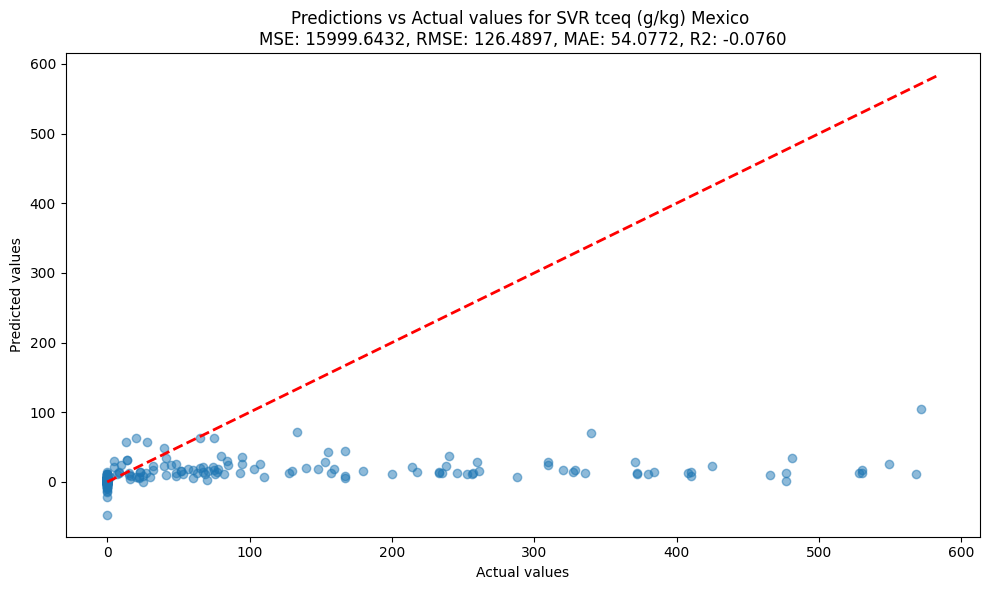

Model saved to D:/tierra/outputs/plots/Mexico-tceq-gkg\SVR.joblib


In [192]:
# models to train
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import joblib

# define list of models to train
models = [
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("Linear Regression", LinearRegression()),
    ("MLP Regressor", MLPRegressor(hidden_layer_sizes=(2,2), max_iter=1000, random_state=42)),
    ("SVR", SVR(kernel='poly'))
]

# baseline mean model
y_pred = [y_train.mean()] * len(y_test)
metrics(f"Baseline model", y_test, y_pred, True)
plot_regression_line(f"Baseline model", y_test, y_pred)

# iterate over the models and train them
for regressor_name, regressor_model in models:
    model, y_test, y_pred = train_model(regressor_model, preprocessor, regressor_name)
    plot_regression_line(regressor_name, y_test, y_pred)
    # plot_feature_importance(regressor_name, model)

    # save the model to a file
    model_file = os.path.join(OUTPUT_DIR, f"{regressor_name}.joblib")
    joblib.dump(model, model_file)
    print(f"Model saved to {model_file}")